# 03. EfficientNetV2-B0 (Functional API, transfer learning)

We take EfficientNetV2-B0, pretrained on ImageNet, swap its 1000-class head for one that predicts our 23 artists, and fine tune it on the WikiArt split. The backbone runs at 224x224, which is the size it was trained on. Training happens in two phases: first the bottom 70% of the backbone stays frozen while we train the head and the top 30%; then a second phase unfreezes roughly the top 55% at a smaller learning rate and fine tunes with MixUp.

Why B0 and not V2-S? V2-S has about three times more parameters, and with only 9,000 training images the extra capacity will overfit before it pays off. B0 is the safer call here. We tried V2-S in an earlier iteration (kept outside this submission for comparison) and it did not improve on the current B0 result. So the capacity wasn't the bottleneck.

Why two phases? The head starts from random weights, so its gradients are large and noisy at first. If we unfreeze the whole backbone while that's happening, those gradients flow all the way down and corrupt the pretrained filters. Phase 1 gives the head time to settle. Phase 2 then lets a sizable portion of the backbone drift at a tiny learning rate, so the lower layers can adapt to WikiArt without being rewritten.

One rule that applies to both phases: every BatchNormalization layer stays frozen. Re-estimating BN statistics on 9k images at batch size 32 is one of the most common ways to silently break transfer learning, and the gain from letting them update is small. Not worth the risk.


### What this notebook does

1. Load the 70/15/15 split at 224x224.
2. Build the input pipeline with prefetch.
3. Apply mild augmentation plus RandomErasing.
4. Wire the EfficientNetV2-B0 backbone and a small head into a Functional model.
5. Phase 1: train the head and the top 30% with AdamW, cosine LR, warmup, class weights, and early stopping.
6. Phase 2: unfreeze the top 55% of the backbone (BN still frozen), add MixUp, and fine tune for up to 12 epochs at a peak LR of 3e-5.
7. Plot curves, evaluate on the test set, apply TTA.
8. Save the averaged predictions for the ensemble notebook.


In [1]:
import os, json, sys
import numpy as np
import matplotlib.pyplot as plt
import math
import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers, losses, regularizers, metrics

# Project utils (cross-platform)
sys.path.append(os.path.abspath(".."))
from utils.plotting import plot_history
from utils.evaluation import evaluate_model

# Cross-platform paths.
SPLIT_DIR  = os.path.join("..", "dataset_split")
SAVED_DIR  = os.path.join("..", "saved_models")
OUTPUT_DIR = os.path.join("..", "outputs", "efficientnet")
CKPT_PATH  = os.path.join(SAVED_DIR, "03_functional_efficientnet_best.keras")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SAVED_DIR,  exist_ok=True)

# Hyper-parameters.
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
SEED           = 42
EPOCHS         = 20          # single phase; EarlyStopping will cut short if val plateaus
WARMUP_EPOCHS  = 2
BASE_LR        = 2e-4
WEIGHT_DECAY   = 5e-4
LABEL_SMOOTH   = 0.15
FREEZE_FRAC    = 0.70        # freeze bottom 70% of backbone blocks
NUM_CLASSES    = 23

keras.utils.set_random_seed(SEED)

with open(os.path.join(SPLIT_DIR, "class_weights.json")) as f:
    class_weight_dict = {int(k): float(v) for k, v in json.load(f).items()}

print(f"Keras {keras.__version__}  ;  TF {tf.__version__}")


Keras 3.13.2  ;  TF 2.20.0


## 1. Load data

`image_dataset_from_directory` reads the split from notebook 01. Labels come back as integers. We one-hot them on the training and validation streams so the loss can apply label smoothing. The test stream stays integer labelled, because `utils.evaluation.evaluate_model` already runs `argmax` on the softmax output.


In [2]:
train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED,
)
val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "val"),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False,
)
test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False,
)

class_names = train_ds.class_names
assert len(class_names) == NUM_CLASSES, f"Expected {NUM_CLASSES} classes, got {len(class_names)}"
print(f"Classes ({NUM_CLASSES}): {class_names}")


Found 9338 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


## 2. Data pipeline

We one-hot the labels and prefetch. That's it. Class imbalance is passed to `fit` via `class_weight=`, which up-weights the loss of under-represented artists inside Keras.

An earlier attempt tried MixUp (a regularisation trick that blends two training images into one) alongside per-sample weights during Phase 1. At the low learning rate Phase 1 uses, the two interacted badly: training accuracy sat permanently below validation accuracy, which made it impossible to read the overfitting signal off the curves. We dropped it here. Phase 2 brings MixUp back (see section 6), but only once the head has stabilised and the dynamics are different — the backbone is partially unfrozen, weight decay is higher, and per-sample weights are out of the picture.


In [3]:
AUTOTUNE = tf.data.AUTOTUNE

def to_onehot(images, labels):
    return images, tf.one_hot(labels, NUM_CLASSES)

train_ds_oh = (
    train_ds
    .map(to_onehot, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
val_ds_oh = (
    val_ds
    .map(to_onehot, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Sanity check.
for x, y in train_ds_oh.take(1):
    print(f"Train batch: images {x.shape}, labels {y.shape}")
for x, y in val_ds_oh.take(1):
    print(f"Val batch  : images {x.shape}, labels {y.shape}")


Train batch: images (32, 224, 224, 3), labels (32, 23)
Val batch  : images (32, 224, 224, 3), labels (32, 23)


## 3. Augmentation

Mild geometric and colour jitter: horizontal flip, small rotation, small zoom, small translation, small brightness and contrast changes. Nothing aggressive, because the things that separate one painter from another are the things aggressive augmentation would destroy.

On top of that we add RandomErasing. During training, a random rectangle covering up to 10% of the image is set to zero, with probability 0.25 per image. It stops the network from anchoring on any single patch of the canvas. In practice, this is also our defence against the signature and watermark shortcut we flagged in notebook 01.


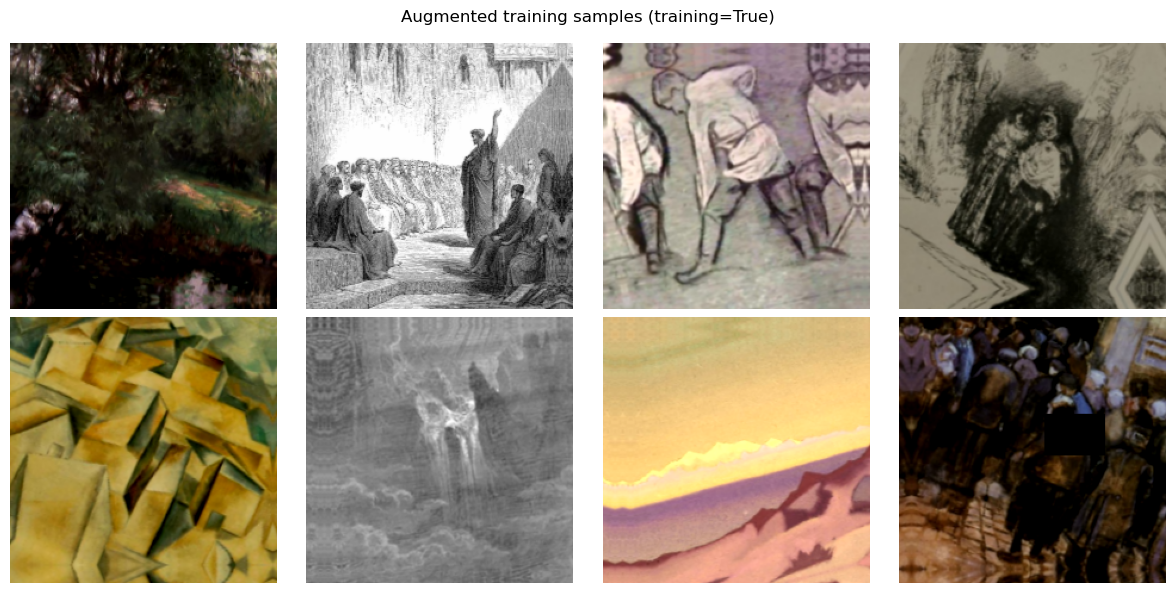

In [4]:
@keras.saving.register_keras_serializable(package="project")
class RandomErasing(layers.Layer):
    """Zero out a random rectangle of each image with probability `p` during training.

    Args:
        p: per-image probability of applying the erase.
        scale: (lo, hi) fraction of image area to erase.
        ratio: (lo, hi) aspect-ratio range of the erased rectangle (w/h).
    """
    def __init__(self, p=0.25, scale=(0.02, 0.10), ratio=(0.3, 3.33), seed=None, **kwargs):
        super().__init__(**kwargs)
        self.p = float(p)
        self.scale = tuple(scale)
        self.ratio = tuple(ratio)
        self.seed = seed

    def _erase_one(self, img):
        shape = tf.shape(img)
        h = shape[0]
        w = shape[1]

        def apply_erasure():
            area = tf.cast(h * w, tf.float32)
            target_area = area * tf.random.uniform([], self.scale[0], self.scale[1])
            aspect = tf.random.uniform([], self.ratio[0], self.ratio[1])
            
            eh = tf.cast(tf.math.sqrt(target_area * aspect), tf.int32)
            ew = tf.cast(tf.math.sqrt(target_area / aspect), tf.int32)
            
            eh = tf.minimum(tf.maximum(eh, 1), h - 1)
            ew = tf.minimum(tf.maximum(ew, 1), w - 1)
            
            top  = tf.random.uniform([], 0, h - eh, dtype=tf.int32)
            left = tf.random.uniform([], 0, w - ew, dtype=tf.int32)
            
            # Build a mask (1 inside the rectangle, 0 elsewhere) and zero those pixels.
            rect = tf.ones([eh, ew, shape[2]], dtype=img.dtype)
            padded = tf.image.pad_to_bounding_box(rect, top, left, h, w)
            return img * (1.0 - padded)

        # This prevents the OperatorNotAllowedInGraphError
        return tf.cond(
            tf.random.uniform([]) >= self.p,
            lambda: img,
            apply_erasure
        )

    def call(self, images, training=False):
        if not training:
            return images
            
        # Note: tf.map_fn remains a severe performance bottleneck.
        return tf.map_fn(self._erase_one, images)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"p": self.p, "scale": list(self.scale),
                    "ratio": list(self.ratio), "seed": self.seed})
        return cfg


augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.08,        seed=SEED),
        layers.RandomZoom(0.12,            seed=SEED),
        layers.RandomTranslation(0.08, 0.08, seed=SEED),
        layers.RandomContrast(0.15,        seed=SEED),
        layers.RandomBrightness(0.15,      seed=SEED, value_range=(0, 255)),
        RandomErasing(p=0.25, scale=(0.02, 0.10)),
    ],
    name="augmentation",
)

# Visual sanity check.
for x, _ in train_ds.take(1):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, img in zip(axes.flat, augmentation(x, training=True)[:8]):
        ax.imshow(tf.cast(img, tf.uint8).numpy())
        ax.axis("off")
    fig.suptitle("Augmented training samples (training=True)")
    plt.tight_layout(); plt.show()



## 4. Model (Functional API)

```
Input(224, 224, 3)
   -> augmentation             (training=True only)
   -> EfficientNet preprocessing
   -> EfficientNetV2-B0 backbone (BN frozen)
   -> GlobalAveragePooling2D
   -> Dropout(0.3)
   -> Dense(128, GELU, L2)
   -> Dropout(0.5)
   -> Dense(23, softmax, L2)
```

The 128-unit bottleneck between two dropouts gives the optimiser something to regularise. We tried the direct 1280 to 23 projection first. Training accuracy saturated almost immediately.

For the partial freeze, we walk the backbone layers in order and freeze the first 70%. Every BatchNormalization layer is frozen regardless of where it sits, and we call `backbone(x, training=False)` on top of that, which forces BN into inference mode even inside the unfrozen top blocks.


In [ ]:
def build_model():
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")

    # 1) Augmentation (training-only).
    x = augmentation(inputs)

    # 2) Pretrained backbone.
    #    include_preprocessing=True: the backbone internally does the correct
    #    Rescaling(1./255) + Normalization(mean/std) that the ImageNet weights
    #    were trained with. DO NOT also apply preprocess_input externally 
    #    for EfficientNetV2 in Keras 3, preprocess_input is the identity
    #    function, so doing so with include_preprocessing=False silently feeds
    #    raw 0-255 values into a network that expects ~zero-mean inputs, which
    #    makes the very first forward pass produce logits with magnitudes of
    #    order ±100, loss > 100, and AdamW immediately crushes the head into
    #    a degenerate uniform-prediction fixed point. This is exactly what
    #     happened on Run 2.
    backbone = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3),
        include_preprocessing=True,
    )
    # Partial freeze: bottom FREEZE_FRAC of backbone layers + every BN layer permanently.
    n_layers = len(backbone.layers)
    freeze_up_to = int(n_layers * FREEZE_FRAC)
    n_bn_frozen = 0
    for i, lyr in enumerate(backbone.layers):
        if isinstance(lyr, layers.BatchNormalization):
            lyr.trainable = False
            n_bn_frozen += 1
        elif i < freeze_up_to:
            lyr.trainable = False
        else:
            lyr.trainable = True

    # training=False forces inference-mode BN even inside the unfrozen top blocks.
    x = backbone(x, training=False)

    # 4) Head: GAP -> Dropout -> Bottleneck -> Dropout -> Dense.
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.30, name="head_drop_1")(x)
    x = layers.Dense(
        128,
        activation="gelu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="bottleneck",
    )(x)
    x = layers.Dropout(0.50, name="head_drop_2")(x)
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_regularizer=regularizers.l2(1e-4),
        name="classifier",
    )(x)

    model = keras.Model(inputs, outputs, name="efficientnetv2b0_transfer")

    # Diagnostics.
    trainable = sum(math.prod(w.shape) for w in model.trainable_weights)
    non_train = sum(math.prod(w.shape) for w in model.non_trainable_weights)
    print(f"Backbone layers: {n_layers} | frozen (by index): {freeze_up_to} "
          f"| BN layers frozen: {n_bn_frozen}")
    print(f"Trainable params:     {trainable:>10,}")
    print(f"Non-trainable params: {non_train:>10,}")
    return model


model = build_model()
model.summary()


Backbone layers: 270 | frozen (by index): 189 | BN layers frozen: 59
Trainable params:      3,235,335
Non-trainable params:  2,850,912


Model: "efficientnetv2b0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_drop_1 (Dropout)           │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_drop_2 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,086,247 (23.22 MB)

 Trainable params: 3,235,335 (12.34 MB)

 Non-trainable params: 2,850,912 (10.88 MB)

## 5. Training, Phase 1

The loss is categorical cross-entropy with label smoothing at 0.15. Label smoothing softens the targets so the model can't assign probability 1.0 to a single class. That makes it harder for the loss to be dominated by the easiest majority-class samples.

Optimiser: AdamW, weight decay 5e-4, gradient clip at norm 1. AdamW applies weight decay separately from the Adam update, which behaves better than plain L2 with adaptive optimisers. The weight decay acts as a second regulariser on top of dropout.

Learning rate: cosine decay over 20 epochs with a 2-epoch linear warmup. The warmup matters because the random head produces big gradients in the first few steps, and we don't want those gradients hitting the backbone at full LR.

Callbacks: `ModelCheckpoint` saves only the best checkpoint, monitoring validation loss. `EarlyStopping` with patience 6 (and `restore_best_weights=True`) cuts training once val loss flatlines. `CSVLogger` writes one row per epoch for the comparison notebook. Class weights go straight into `fit` so Keras applies them inside the loss.


In [ ]:
# Phase 1 training.
# If a Phase 1 checkpoint is already on disk, we reload its weights and skip
# model.fit(). Everything else still has to run (schedule, metrics, compile),
# because Phase 2 later re-compiles the same 'model' and expects topk_metrics.

cardinality = train_ds_oh.cardinality().numpy()
if cardinality <= 0:
    raise ValueError(
        "Dataset cardinality is unknown or infinite. "
        "You must explicitly define steps_per_epoch."
    )
steps_per_epoch = int(cardinality)
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = steps_per_epoch * WARMUP_EPOCHS
decay_steps     = total_steps - warmup_steps

# Cosine schedule with a short linear warmup.
lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0,
    decay_steps=decay_steps,
    alpha=0.0,
    warmup_target=BASE_LR,
    warmup_steps=warmup_steps,
)

topk_metrics = [
    metrics.TopKCategoricalAccuracy(k=1, name="top1_accuracy"),
    metrics.TopKCategoricalAccuracy(k=3, name="top3_accuracy"),
    metrics.TopKCategoricalAccuracy(k=5, name="top5_accuracy"),
]

model.compile(
    optimizer=optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=topk_metrics,
)

MONITOR_METRIC = "val_loss"
MONITOR_MODE   = "min"

if os.path.exists(CKPT_PATH):
    print(f"Phase 1 checkpoint already on disk, reloading weights and skipping fit:")
    print(f"  {CKPT_PATH}")
    # load_weights into the already-built model so that 'model' and its
    # inner `backbone` reference are preserved for Phase 2.
    model.load_weights(CKPT_PATH)
    history = None
else:
    cb_list = [
        callbacks.ModelCheckpoint(
            CKPT_PATH,
            monitor=MONITOR_METRIC,
            mode=MONITOR_MODE,
            save_best_only=True,
            verbose=1,
        ),
        callbacks.EarlyStopping(
            monitor=MONITOR_METRIC,
            mode=MONITOR_MODE,
            patience=6,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.CSVLogger(os.path.join(OUTPUT_DIR, "train_log.csv")),
    ]

    history = model.fit(
        train_ds_oh,
        validation_data=val_ds_oh,
        epochs=EPOCHS,
        callbacks=cb_list,
        class_weight=class_weight_dict,
        verbose=2,
    )


Phase 1 checkpoint already on disk, reloading weights and skipping fit:
  ..\saved_models\03_functional_efficientnet_best.keras


c:\Users\pedro\anaconda3\envs\Deeplearning\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 1 variables whereas the saved optimizer has 81 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### Phase 1 curves

Two things to watch on the plots below.

First, the gap between training and validation accuracy. Past 10 percentage points it's a sign that the model is starting to memorise rather than generalise.

Second, the validation loss curve. It should drop, flatten, then start rising. The rising point is where early stopping fires and the weights get rewound.


In [8]:
# Plot Phase 1 training curves. If Phase 1 was skipped (checkpoint reloaded),
# `history` is None and we have nothing to plot, so we just skip this step.

if history is None:
    print("Phase 1 was skipped (checkpoint reloaded). Nothing to plot for Phase 1.")
else:
    fig = plot_history(
        history,
        "EfficientNetV2-B0 (Functional)",
        accuracy_key="top1_accuracy",
        val_accuracy_key="val_top1_accuracy",
    )
    fig.savefig(
        os.path.join(OUTPUT_DIR, "training_curves.png"),
        dpi=150, bbox_inches="tight",
    )


Phase 1 was skipped (checkpoint reloaded). Nothing to plot for Phase 1.


## 6. Phase 2

Earlier Phase 2 recipes did not improve on Phase 1. Unfreezing the full backbone at LR 1e-5 regressed to val Top-1 ~0.63; narrowing to the top third at a very small LR held val Top-1 flat at ~0.776 while val_loss climbed and train Top-1 drifted 88 → 91. The second pattern is the model sharpening its softmax on the training set instead of learning: the LR was too small to move the backbone out of the Phase 1 basin, and the head had no extra regulariser to absorb the added capacity.

This run widens the tuned slice to roughly the top 55% of the backbone and raises the peak LR to 3e-5, with a 1-epoch linear warmup and cosine decay to 1e-7. To keep those extra degrees of freedom from overfitting, we add MixUp (alpha=0.2) on the training stream, raise AdamW weight decay to 1e-3, and nudge the head dropouts from 0.30/0.50 to 0.35/0.55. Label smoothing stays at 0.15 — relaxing it in the previous attempt was the wrong direction. BN layers remain frozen throughout.

Training runs for up to 12 epochs with `EarlyStopping(patience=4)` on val_loss. All Phase 2 artefacts land under `_test6`,suffixed filenames so the Phase 1 shipped files are never touched. The ship selection in the cell below picks whichever of Phase 1 and Phase 2 has the higher validation Top-1; if this recipe regresses, Phase 1 ships unchanged.


In [9]:
import numpy as np
m = keras.models.load_model(CKPT_PATH)
test_metrics = m.evaluate(test_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))),
                          verbose=0, return_dict=True)
print("Phase 1 checkpoint, test set:", test_metrics)

Phase 1 checkpoint, test set: {'loss': 1.5050030946731567, 'top1_accuracy': 0.7601199150085449, 'top3_accuracy': 0.9035482406616211, 'top5_accuracy': 0.9450274705886841}


In [10]:
# Phase 2 (test6) — widen the tuned slice, raise the LR, add MixUp.

PHASE2_CKPT_PATH     = os.path.join(SAVED_DIR,  "03_functional_efficientnet_phase2_best_test6.keras")
PHASE2_LOG_PATH      = os.path.join(OUTPUT_DIR, "phase2_log_test6.csv")
PHASE2_HIST_PATH     = os.path.join(OUTPUT_DIR, "phase2_history_test6.json")
PHASE2_EPOCHS        = 12
PHASE2_PATIENCE      = 4
PHASE2_BASE_LR       = 3e-5
PHASE2_MIN_LR        = 1e-7
PHASE2_WARMUP_EPOCHS = 1
PHASE2_WEIGHT_DECAY  = 1e-3
PHASE2_LABEL_SMOOTH  = 0.15
PHASE2_UNFREEZE_FRAC = 0.55          # top ~55 % of backbone layers trainable
MIXUP_ALPHA          = 0.2

# 1) Reload Phase 1 best. keeps backbone(x, training=False) baked into the graph.
assert os.path.exists(CKPT_PATH), f"Phase 1 checkpoint missing: {CKPT_PATH}"
phase1_best = keras.models.load_model(CKPT_PATH)

backbone_in_loaded = None
for lyr in phase1_best.layers:
    if isinstance(lyr, keras.Model) and "efficientnetv2" in lyr.name.lower():
        backbone_in_loaded = lyr
        break
assert backbone_in_loaded is not None, "Could not find EfficientNetV2 backbone in loaded model."

# 2) Sanity check BEFORE unfreeze: confirm Phase 1 weights actually loaded.
sanity = phase1_best.evaluate(val_ds_oh, verbose=0, return_dict=True)
sanity_top1 = sanity.get("top1_accuracy", sanity.get("compile_metrics", -1.0))
print(f"Pre-Phase-2 sanity check - val top1 = {sanity_top1:.4f} (expected ~0.77).")

# 3) Unfreeze top ~55 % of the backbone; BN layers stay frozen regardless.
n_layers      = len(backbone_in_loaded.layers)
unfreeze_from = int(n_layers * (1.0 - PHASE2_UNFREEZE_FRAC))
n_unfrozen = n_bn_frozen = n_kept_frozen = 0
for i, lyr in enumerate(backbone_in_loaded.layers):
    if isinstance(lyr, layers.BatchNormalization):
        lyr.trainable = False
        n_bn_frozen += 1
    elif i >= unfreeze_from:
        lyr.trainable = True
        n_unfrozen += 1
    else:
        lyr.trainable = False
        n_kept_frozen += 1
print(f"Phase 2 unfreeze: {n_unfrozen} trainable, {n_kept_frozen} frozen, {n_bn_frozen} BN frozen.")

# 4) Nudge head dropouts up so the widened backbone has more regularisation pressure.
for name, new_rate in [("head_drop_1", 0.35), ("head_drop_2", 0.55)]:
    try:
        phase1_best.get_layer(name).rate = new_rate
    except ValueError:
        pass  # layer name may differ in older builds; fall back to Phase 1 rates

# 5) LR schedule: 1-epoch linear warmup to PHASE2_BASE_LR, then cosine decay to PHASE2_MIN_LR.
phase2_steps_per_epoch = int(train_ds_oh.cardinality().numpy())
phase2_total_steps     = phase2_steps_per_epoch * PHASE2_EPOCHS
phase2_lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0,
    decay_steps=phase2_total_steps,
    alpha=PHASE2_MIN_LR / PHASE2_BASE_LR,
    warmup_target=PHASE2_BASE_LR,
    warmup_steps=phase2_steps_per_epoch * PHASE2_WARMUP_EPOCHS,
)

phase1_best.compile(
    optimizer=optimizers.AdamW(
        learning_rate=phase2_lr_schedule,
        weight_decay=PHASE2_WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=losses.CategoricalCrossentropy(label_smoothing=PHASE2_LABEL_SMOOTH),
    metrics=topk_metrics,
)

# 6) MixUp on the one-hot training stream. Blends pairs within each batch.
def mixup_batch(images, labels, alpha=MIXUP_ALPHA):
    g1 = tf.random.gamma([1], alpha)
    g2 = tf.random.gamma([1], alpha)
    lam = g1 / (g1 + g2)
    lam_x = tf.reshape(lam, [1, 1, 1, 1])
    lam_y = tf.reshape(lam, [1, 1])
    idx = tf.random.shuffle(tf.range(tf.shape(images)[0]))
    images_mix = lam_x * images + (1.0 - lam_x) * tf.gather(images, idx)
    labels_mix = lam_y * labels + (1.0 - lam_y) * tf.gather(labels, idx)
    return images_mix, labels_mix

train_ds_mixup = train_ds_oh.map(mixup_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# 7) Callbacks. Explicit append=False so CSVLogger actually flushes from epoch 0.
cb_phase2 = [
    callbacks.ModelCheckpoint(PHASE2_CKPT_PATH, monitor="val_loss", mode="min",
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=PHASE2_PATIENCE,
                            restore_best_weights=True, verbose=1),
    callbacks.CSVLogger(PHASE2_LOG_PATH, append=False),
]

# 8) Fit. class_weight is not compatible with MixUp soft labels; Phase 1 weights already
#    encode the class-weighted prior, so we let MixUp + label smoothing carry from here.
history_phase2 = phase1_best.fit(
    train_ds_mixup,
    validation_data=val_ds_oh,
    epochs=PHASE2_EPOCHS,
    callbacks=cb_phase2,
    verbose=2,
)

# 9) Back up history to JSON in case CSVLogger drops rows again.
try:
    with open(PHASE2_HIST_PATH, "w") as f:
        json.dump({k: [float(v) for v in vs] for k, vs in history_phase2.history.items()},
                  f, indent=2)
        f.flush(); os.fsync(f.fileno())
except Exception as e:
    print(f"Warning: failed to write {PHASE2_HIST_PATH}: {e}")


Pre-Phase-2 sanity check - val top1 = 0.7761 (expected ~0.77).
Phase 2 unfreeze: 119 trainable, 92 frozen, 59 BN frozen.
Epoch 1/12

Epoch 1: val_loss improved from None to 1.50877, saving model to ..\saved_models\03_functional_efficientnet_phase2_best_test6.keras

Epoch 1: finished saving model to ..\saved_models\03_functional_efficientnet_phase2_best_test6.keras
292/292 - 461s - 2s/step - loss: 1.7255 - top1_accuracy: 0.8009 - top3_accuracy: 0.9035 - top5_accuracy: 0.9384 - val_loss: 1.5088 - val_top1_accuracy: 0.7651 - val_top3_accuracy: 0.9065 - val_top5_accuracy: 0.9420
Epoch 2/12

Epoch 2: val_loss improved from 1.50877 to 1.49967, saving model to ..\saved_models\03_functional_efficientnet_phase2_best_test6.keras

Epoch 2: finished saving model to ..\saved_models\03_functional_efficientnet_phase2_best_test6.keras
292/292 - 354s - 1s/step - loss: 1.7028 - top1_accuracy: 0.8011 - top3_accuracy: 0.9052 - top5_accuracy: 0.9381 - val_loss: 1.4997 - val_top1_accuracy: 0.7651 - val_top3

### Phase 1 vs Phase 2

We evaluate both checkpoints on the validation set and keep whichever has the higher top-1 accuracy. The winning path goes into `SHIPPED_CKPT` and drives the rest of the notebook. If Phase 2 regressed, the submitted model is Phase 1, with no manual file shuffling needed.


Phase 1 val top-1: 0.7761
Phase 2 val top-1: 0.7846

Shipping Phase 2 checkpoint: ..\saved_models\03_functional_efficientnet_phase2_best_test6.keras


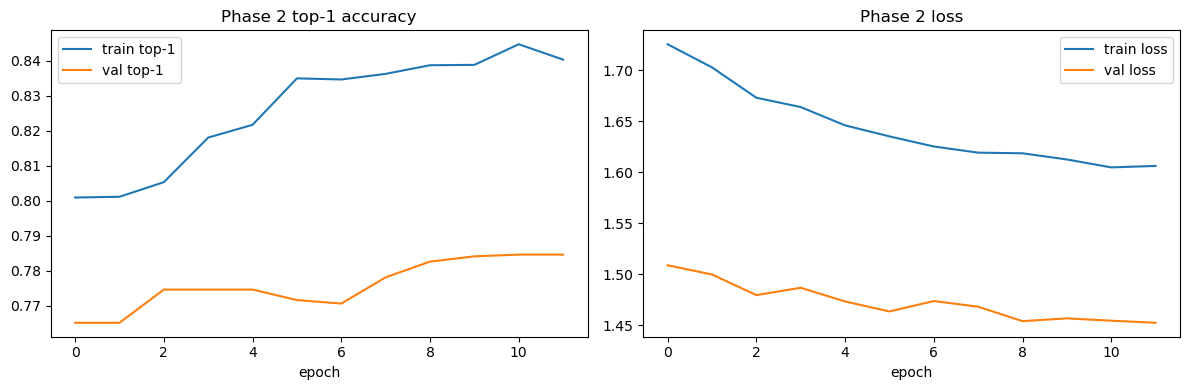

In [11]:
# Decide which checkpoint to ship — on the validation set, not the test set.

def _val_top1(path):
    m = keras.models.load_model(path)
    val_metrics = m.evaluate(val_ds_oh, verbose=0, return_dict=True)
    # Key is either 'top1_accuracy' or 'compile_metrics' depending on Keras build;
    # look up robustly.
    for k in ("top1_accuracy", "val_top1_accuracy", "accuracy"):
        if k in val_metrics:
            return float(val_metrics[k])
    # Fallback: any key containing 'top1'.
    for k, v in val_metrics.items():
        if "top1" in k:
            return float(v)
    raise KeyError(f"Could not find top1 in metrics: {list(val_metrics)}")

phase1_val_top1 = _val_top1(CKPT_PATH)
phase2_val_top1 = _val_top1(PHASE2_CKPT_PATH) if os.path.exists(PHASE2_CKPT_PATH) else -1.0
print(f"Phase 1 val top-1: {phase1_val_top1:.4f}")
print(f"Phase 2 val top-1: {phase2_val_top1:.4f}")

if phase2_val_top1 > phase1_val_top1:
    SHIPPED_CKPT = PHASE2_CKPT_PATH
    shipped_label = "Phase 2"
else:
    SHIPPED_CKPT = CKPT_PATH
    shipped_label = "Phase 1"
print(f"\nShipping {shipped_label} checkpoint: {SHIPPED_CKPT}")

# Also plot Phase 2 curves next to the Phase 1 ones for the report.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if history_phase2 is not None:
    axes[0].plot(history_phase2.history.get("top1_accuracy", []), label="train top-1")
    axes[0].plot(history_phase2.history.get("val_top1_accuracy", []), label="val top-1")
    axes[0].set_title("Phase 2 top-1 accuracy"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(history_phase2.history.get("loss", []),     label="train loss")
    axes[1].plot(history_phase2.history.get("val_loss", []), label="val loss")
    axes[1].set_title("Phase 2 loss"); axes[1].set_xlabel("epoch"); axes[1].legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "phase2_curves_test6.png"), dpi=150, bbox_inches="tight")
plt.show()


## 7. Evaluation on the test set

We reload the shipped checkpoint from disk instead of trusting the in-memory copy, so evaluation is reproducible when the notebook is run again later. `utils.evaluation.evaluate_model` returns Top-1/3/5 accuracy, macro F1, weighted F1, the confusion matrix, and the top-10 off-diagonal confusions.


--------- Classification report ---------
Top-1: 0.7721  Top-3: 0.9060  Top-5: 0.9435
macro-F1: 0.7467    weighted-F1: 0.7680

                       precision    recall  f1-score   support

       Albrecht_Durer       0.87      0.84      0.85        87
      Boris_Kustodiev       0.63      0.50      0.56        66
     Camille_Pissarro       0.79      0.73      0.76        93
        Childe_Hassam       0.84      0.55      0.67        58
         Claude_Monet       0.80      0.68      0.73       140
          Edgar_Degas       0.83      0.70      0.76        64
        Eugene_Boudin       0.74      0.93      0.83        59
         Gustave_Dore       0.87      0.95      0.91        79
           Ilya_Repin       0.62      0.68      0.65        56
      Ivan_Aivazovsky       0.95      0.89      0.92        61
        Ivan_Shishkin       0.65      0.84      0.73        55
  John_Singer_Sargent       0.74      0.89      0.81        82
         Marc_Chagall       0.92      0.67      0.77 

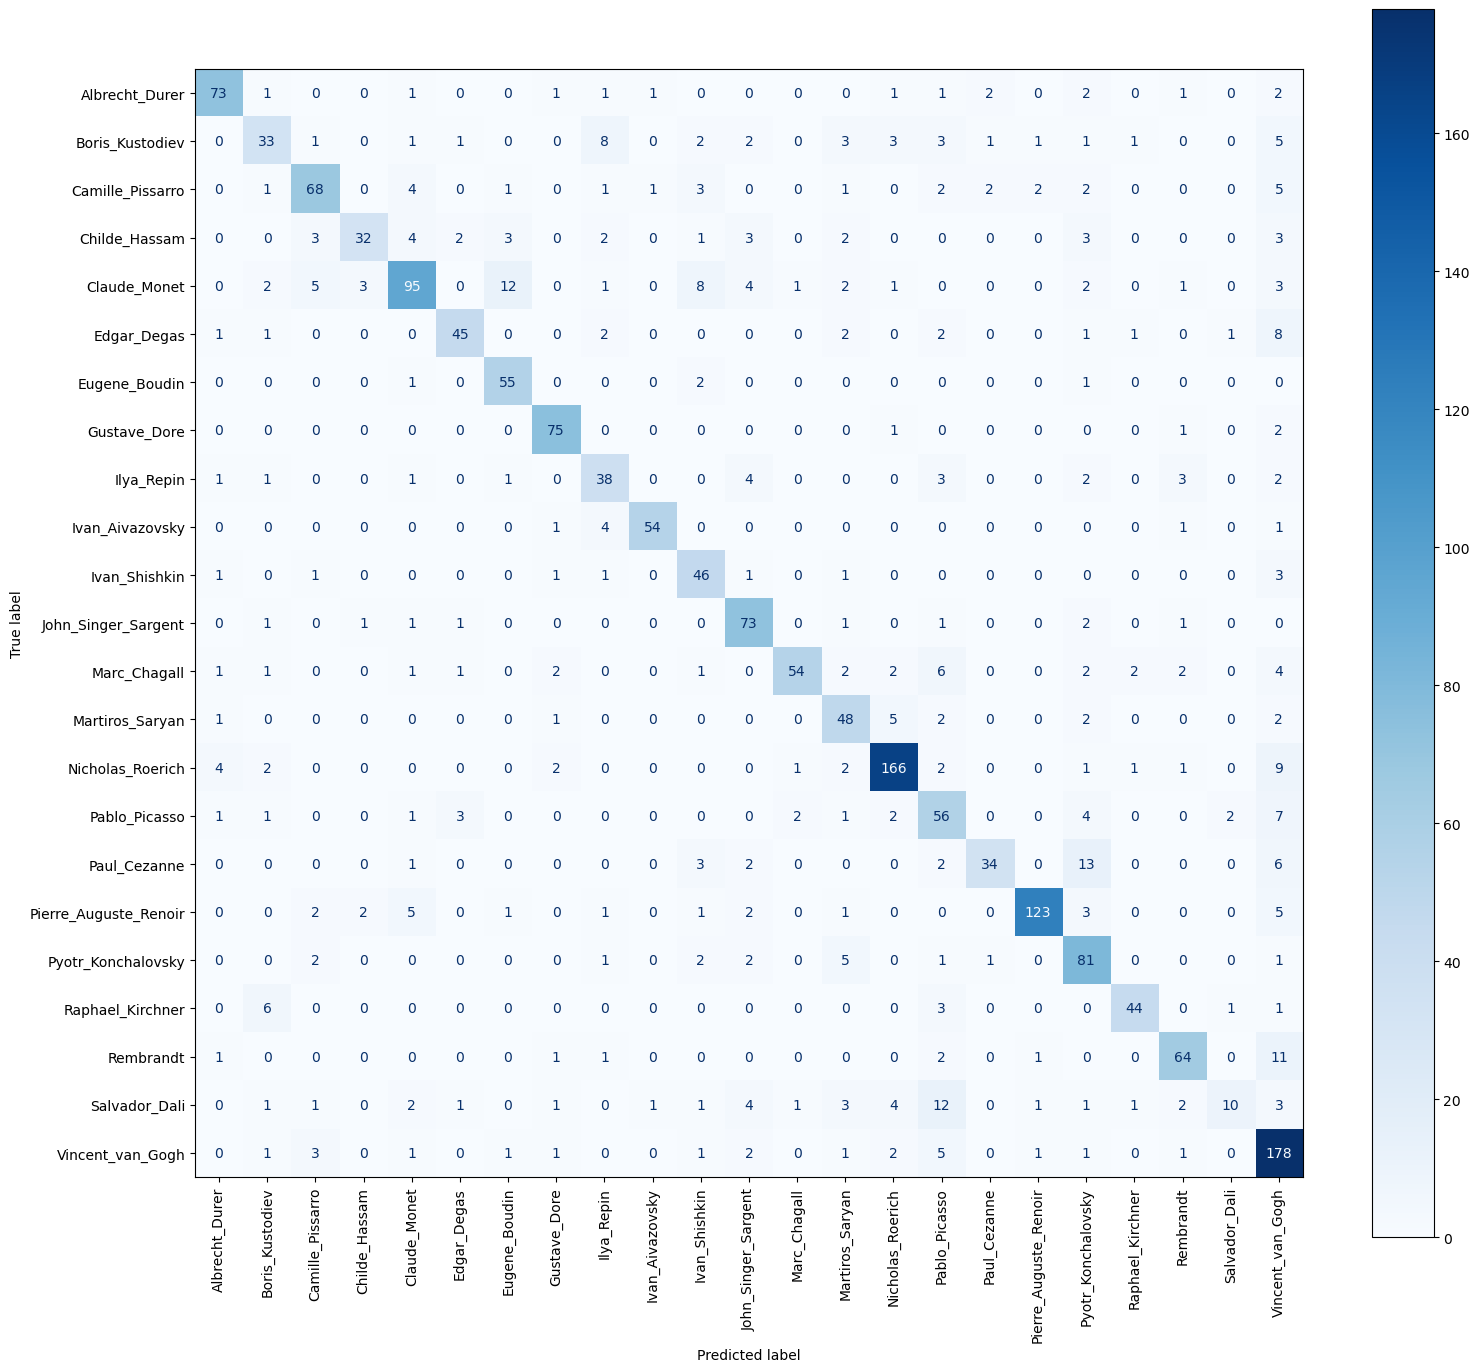

--------- Top 10 misclassifications ---------
                    True class  as  Predicted class                 Count
------------------------------------------------------------------------------------------
                  Paul_Cezanne  as  Pyotr_Konchalovsky              13
                  Claude_Monet  as  Eugene_Boudin                   12
                 Salvador_Dali  as  Pablo_Picasso                   12
                     Rembrandt  as  Vincent_van_Gogh                11
              Nicholas_Roerich  as  Vincent_van_Gogh                9
               Boris_Kustodiev  as  Ilya_Repin                      8
                  Claude_Monet  as  Ivan_Shishkin                   8
                   Edgar_Degas  as  Vincent_van_Gogh                8
                 Pablo_Picasso  as  Vincent_van_Gogh                7
                  Marc_Chagall  as  Pablo_Picasso                   6


In [12]:
best_model = keras.models.load_model(SHIPPED_CKPT)
eff_results = evaluate_model(best_model, test_ds, class_names)


### 7.1 Test-Time Augmentation (TTA)

TTA is a free accuracy boost. We predict on the original image and on its horizontally flipped version, then average the two softmax outputs. Horizontal flip is safe here because paintings don't have an intrinsic left/right we care about preserving.

The averaged softmax is what we save for the ensemble notebook. That way the ensemble picks up the TTA signal without having to recompute it.


In [ ]:
def tta_predict(model, ds):
    """Return (probs, y_true) averaged over [identity, horizontal-flip] TTA."""
    probs_list, y_list = [], []
    for images, labels in ds:
        p1 = model.predict(images,                          verbose=0)
        p2 = model.predict(tf.image.flip_left_right(images), verbose=0)
        probs_list.append((p1 + p2) / 2.0)
        y_list.append(labels.numpy())
    return np.concatenate(probs_list), np.concatenate(y_list)


y_pred_probs_tta, y_true = tta_predict(best_model, test_ds)
y_pred_tta               = np.argmax(y_pred_probs_tta, axis=1)

def topk_acc(probs, y, k):
    topk = np.argsort(probs, axis=1)[:, -k:]
    return float(np.mean(np.any(topk == y[:, None], axis=1)))

from sklearn.metrics import f1_score
tta_top1 = float(np.mean(y_pred_tta == y_true))
tta_top3 = topk_acc(y_pred_probs_tta, y_true, 3)
tta_top5 = topk_acc(y_pred_probs_tta, y_true, 5)
tta_macro_f1    = float(f1_score(y_true, y_pred_tta, average="macro",    zero_division=0))
tta_weighted_f1 = float(f1_score(y_true, y_pred_tta, average="weighted", zero_division=0))

print("Test set, with TTA (original + horizontal flip)")
print(f"Top-1: {tta_top1:.4f}   Top-3: {tta_top3:.4f}   Top-5: {tta_top5:.4f}")
print(f"macro-F1: {tta_macro_f1:.4f}    weighted-F1: {tta_weighted_f1:.4f}")
print()
print(f"No-TTA baseline: Top-1 {eff_results['top_k'][1]:.4f}  "
      f"macro-F1 {eff_results['macro_f1']:.4f}")


--------- Test set, with TTA (original + horizontal flip) ---------
Top-1: 0.7811   Top-3: 0.9045   Top-5: 0.9440
macro-F1: 0.7549    weighted-F1: 0.7767

No-TTA baseline: Top-1 0.7721  macro-F1 0.7467


## 8. Predictions for the ensemble

We save the TTA-averaged softmax so notebook 06 can average it element-wise with the other models' probability vectors. `shuffle=False` on `test_ds` guarantees row order matches every other notebook's `test_probs.npz`, which is what makes the ensemble's average meaningful.


In [14]:
results = {
    "model":         "EfficientNetV2-B0",
    "api":           "functional",
    "img_size":      list(IMG_SIZE),
    "n_params":      int(best_model.count_params()),
    "top1":          tta_top1,
    "top3":          tta_top3,
    "top5":          tta_top5,
    "macro_f1":      tta_macro_f1,
    "weighted_f1":   tta_weighted_f1,
    "shipped_phase": shipped_label,
    "notes":         "TTA: mean(softmax(x), softmax(flip_lr(x)))",
}
results_path = os.path.join(OUTPUT_DIR, "results.json")
try:
    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)
        f.flush(); os.fsync(f.fileno())
except Exception as e:
    print(f"Warning: results.json write failed: {e}")

np.savez(
    os.path.join(OUTPUT_DIR, "test_probs.npz"),
    probs=y_pred_probs_tta,
    y_true=y_true,
)

# Also drop a _test6 snapshot so the new run is traceable even after the ship file is
# overwritten by a future Phase 2.
if shipped_label == "Phase 2":
    try:
        with open(os.path.join(OUTPUT_DIR, "results_test6.json"), "w") as f:
            json.dump(results, f, indent=2)
            f.flush(); os.fsync(f.fileno())
    except Exception as e:
        print(f"Warning: results_test6.json write failed: {e}")
    np.savez(
        os.path.join(OUTPUT_DIR, "test_probs_test6.npz"),
        probs=y_pred_probs_tta,
        y_true=y_true,
    )

print(f"Saved results.json and test_probs.npz under {OUTPUT_DIR}")


Saved results.json and test_probs.npz under ..\outputs\efficientnet
